# Workbook 25 — impactor to a self-heating DT starter

This first-pass workbook asks what **projectile mass and speed** are needed to create the early DT starter that launches the Trajan DT-vein network. It deliberately separates two requirements:

1. **energy inventory:** enough projectile kinetic energy must become cold compression and ion/electron heat in the DT starter;
2. **pressure and pulse concentration:** the shaped target must concentrate that energy to the starter pressure and on its very short confinement clock.

A projectile can pass the first requirement and fail the second by orders of magnitude. This notebook therefore produces an energy-sized projectile and reports the still-required pressure amplification and temporal compression. It is an auditable zero-dimensional screen, not an impact/cratering or convergent-hydrodynamics simulation.

The starter here is the **early driver starter**. The separate central DT kernel that should ignite near peak compression belongs to workbooks 36/37.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
while repo_root.name != 'CNO' and repo_root != repo_root.parent:
    repo_root = repo_root.parent
source_root = repo_root / 'analysis' / 'src'
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from cno_sweep.impactor import (
    IMPACTOR_MATERIALS,
    dt_starter_state,
    impactor_requirement,
    minimum_self_heating_dt_starter,
)

print('Workbook model: uniform compressed DT starter + energy-sized spherical impactor')

Workbook model: uniform compressed DT starter + energy-sized spherical impactor


## What counts as a self-heating starter in this workbook

For equimolar DT at fixed compressed density, finite depletion over one effective sound-crossing time is calculated exactly:

$$f=\frac{n_0\langle\sigma v\rangle\tau_h}{1+n_0\langle\sigma v\rangle\tau_h}.$$

The starter passes only when both conditions hold:

$$f\ge f_{target},$$

$$P_{\alpha,dep} \ge P_{brem}+\frac{u_{thermal}}{\tau_h}.$$

Alpha deposition is approximated as $1-\exp[-(\rho R)/(\rho R)_\alpha]$. Cold-electron compression uses the finite-density electron EOS already in the library. Ion and electron thermal energies are reported separately, avoiding a zero-temperature-degeneracy plus classical-electron double count.

This criterion is stricter than asking for a rapid initial DT reaction, but it still omits a resolved alpha-heated burn wave, shocks, conduction, and hotspot-shell work. Passing it means **candidate starter**, not demonstrated ignition.

## Provisional review cases

These are intentionally editable first-pass assumptions. `likely` is not a measured target efficiency; it is the current middle estimate to challenge. `conservative` simultaneously asks for lower compression, shorter effective confinement, a larger alpha stopping column, more burn, and poorer kinetic-to-starter coupling. Because several penalties move together, it is a bracket rather than a statistical confidence interval. The likely 3 kg/m2 alpha column is the familiar 0.3 g/cm2 DT-hotspot ignition scale described in this [LLNL ignition review](https://www.osti.gov/servlets/purl/1755219); 5 kg/m2 is a deliberately less favorable screen, not an independently evaluated stopping calculation.

In [2]:
cases = {
    'likely': {
        'compression_ratio': 1000.0,
        'ion_temperature_keV': 10.0,
        'hydrodynamic_coefficient': 1.0,
        'alpha_stopping_rho_r_kg_m2': 3.0,
        'target_burn_fraction': 0.10,
        'useful_state_coupling': 0.10,
        'pressure_coefficient': 0.50,
    },
    'conservative': {
        'compression_ratio': 300.0,
        'ion_temperature_keV': 8.0,
        'hydrodynamic_coefficient': 0.50,
        'alpha_stopping_rho_r_kg_m2': 5.0,
        'target_burn_fraction': 0.20,
        'useful_state_coupling': 0.02,
        'pressure_coefficient': 0.50,
    },
}
pd.DataFrame(cases).T.rename_axis('case')

,compression_ratio,ion_temperature_keV,hydrodynamic_coefficient,alpha_stopping_rho_r_kg_m2,target_burn_fraction,useful_state_coupling,pressure_coefficient
case,,,,,,,
likely,1000.0,10.0,1.0,3.0,0.1,0.10,0.5
conservative,300.0,8.0,0.5,5.0,0.2,0.02,0.5


## Minimum DT starter over temperature and compression

The next sweep finds the smallest initial cryogenic DT radius that passes the chosen 10% burn and self-heating-power gates. It holds the alpha range and whole-sphere confinement coefficient at the likely values so temperature and compression can be read independently.

In [3]:
compressions = np.array([30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0])
temperatures_keV = np.array([5.0, 8.0, 10.0, 15.0, 20.0, 30.0])
starter_rows = []
for compression in compressions:
    for temperature in temperatures_keV:
        try:
            starter = minimum_self_heating_dt_starter(
                compression_ratio=compression,
                ion_temperature_keV=temperature,
                hydrodynamic_coefficient=1.0,
                alpha_stopping_rho_r_kg_m2=3.0,
                target_burn_fraction=0.10,
            )
            starter_rows.append({
                'compression': compression,
                'kT (keV)': temperature,
                'initial radius (mm)': starter.initial_radius_m * 1e3,
                'compressed radius (um)': starter.compressed_radius_m * 1e6,
                'mass (mg)': starter.mass_kg * 1e6,
                'rhoR (kg/m2)': starter.rho_r_kg_m2,
                'useful state energy (MJ)': starter.useful_state_energy_j / 1e6,
                'burn in one hydro': starter.burn_fraction_one_hydro,
                'self-heating margin': starter.self_heating_power_margin,
            })
        except ValueError:
            starter_rows.append({
                'compression': compression, 'kT (keV)': temperature,
                'initial radius (mm)': np.nan, 'compressed radius (um)': np.nan,
                'mass (mg)': np.nan, 'rhoR (kg/m2)': np.nan,
                'useful state energy (MJ)': np.nan, 'burn in one hydro': np.nan,
                'self-heating margin': np.nan,
            })
starter_grid = pd.DataFrame(starter_rows)
starter_grid.pivot(index='kT (keV)', columns='compression', values='initial radius (mm)')

compression,30.0,100.0,300.0,1000.0,3000.0,10000.0
kT (keV),,,,,,
5.0,22.962117,10.291128,4.948658,2.219574,1.069633,0.483338
8.0,6.469882,2.899587,1.394140,0.625028,0.300836,0.135368
10.0,3.964022,1.776513,0.854130,0.382882,0.184224,0.082798
15.0,1.980411,0.887516,0.426692,0.191248,0.091983,0.041285
20.0,1.426419,0.639242,0.307324,0.137738,0.066236,0.029712
30.0,1.145240,0.513231,0.246739,0.110579,0.053169,0.023839


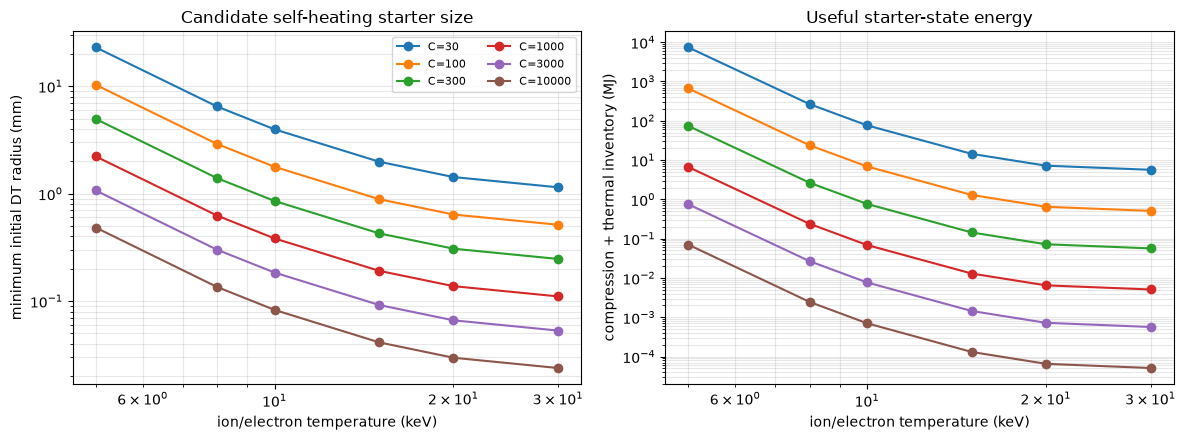

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for compression, group in starter_grid.groupby('compression'):
    axes[0].loglog(group['kT (keV)'], group['initial radius (mm)'], marker='o', label=f'C={compression:g}')
    axes[1].loglog(group['kT (keV)'], group['useful state energy (MJ)'], marker='o')
axes[0].set(xlabel='ion/electron temperature (keV)', ylabel='minimum initial DT radius (mm)', title='Candidate self-heating starter size')
axes[0].legend(ncols=2, fontsize=8)
axes[1].set(xlabel='ion/electron temperature (keV)', ylabel='compression + thermal inventory (MJ)', title='Useful starter-state energy')
for ax in axes:
    ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

The curves are not monotonic design optima. Higher temperature speeds DT burn but costs more heat; compression increases density and shortens the physical alpha range, while also requiring cold-compression work and a much higher pressure. The minimum radius is usually set by the requested burn clock after alpha deposition becomes nearly complete. A later implosion calculation must determine which compression is actually reachable.

## Likely and conservative candidate starters

In [5]:
reference_starters = {}
reference_rows = []
for name, case in cases.items():
    starter = minimum_self_heating_dt_starter(
        compression_ratio=case['compression_ratio'],
        ion_temperature_keV=case['ion_temperature_keV'],
        hydrodynamic_coefficient=case['hydrodynamic_coefficient'],
        alpha_stopping_rho_r_kg_m2=case['alpha_stopping_rho_r_kg_m2'],
        target_burn_fraction=case['target_burn_fraction'],
    )
    reference_starters[name] = starter
    reference_rows.append({
        'case': name,
        'initial DT radius (mm)': starter.initial_radius_m * 1e3,
        'compressed DT radius (um)': starter.compressed_radius_m * 1e6,
        'DT mass (mg)': starter.mass_kg * 1e6,
        'compressed density (kg/m3)': starter.compressed_density_kg_m3,
        'rhoR (kg/m2)': starter.rho_r_kg_m2,
        'alpha deposited': starter.alpha_deposition_fraction,
        'hydro time (ps)': starter.hydrodynamic_time_s * 1e12,
        'burn in one hydro': starter.burn_fraction_one_hydro,
        'self-heating power margin': starter.self_heating_power_margin,
        'hot pressure (Pa)': starter.hot_pressure_pa,
        'cold compression (MJ)': starter.cold_electron_compression_energy_j / 1e6,
        'ion heating (MJ)': starter.ion_thermal_energy_j / 1e6,
        'electron heating (MJ)': starter.electron_thermal_energy_j / 1e6,
        'useful state energy (MJ)': starter.useful_state_energy_j / 1e6,
        'fusion yield / hydro (MJ)': starter.fusion_yield_one_hydro_j / 1e6,
    })
reference_table = pd.DataFrame(reference_rows).set_index('case')
reference_table.T

case,likely,conservative
initial DT radius (mm),3.828818e-01,6.273632e+00
compressed DT radius (um),3.828818e+01,9.371561e+02
DT mass (mg),5.877910e-02,2.585745e+02
compressed density (kg/m3),2.500000e+05,7.500000e+04
rhoR (kg/m2),9.572046e+00,7.028671e+01
alpha deposited,9.588562e-01,9.999992e-01
hydro time (ps),3.374299e+01,4.618066e+02
burn in one hydro,1.000000e-01,2.000000e-01
self-heating power margin,3.360467e+00,3.708442e+00
hot pressure (Pa),1.931318e+17,4.632935e+16


## Projectile mass-speed locus

For a declared useful-state coupling $\eta_E$, the energy-sized projectile obeys

$$m_p=\frac{2E_{starter}}{\eta_E v_p^2}.$$

For the separate pressure screen, direct ram/stagnation pressure is represented as

$$P_{direct}=C_P\rho_p v_p^2.$$

The notebook reports $P_{starter}/P_{direct}$ as the pressure amplification still demanded of the shaped target. No assumed focusing factor is used to make this ratio pass. Tungsten is the reference projectile solely because its high density minimizes spherical projectile size and increases the direct pressure scale.

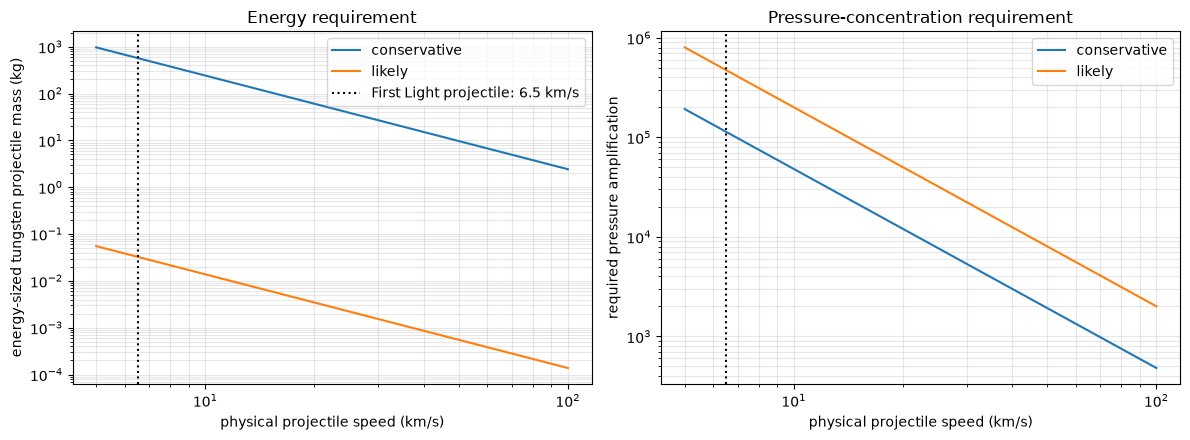

In [6]:
velocities_m_s = np.geomspace(5e3, 100e3, 160)
requirements = []
for case_name, case in cases.items():
    for velocity in velocities_m_s:
        req = impactor_requirement(
            reference_starters[case_name],
            case_name=case_name,
            material=IMPACTOR_MATERIALS['tungsten'],
            velocity_m_s=velocity,
            useful_state_coupling=case['useful_state_coupling'],
            pressure_coefficient=case['pressure_coefficient'],
        )
        requirements.append({
            'case': case_name,
            'velocity (km/s)': velocity / 1e3,
            'projectile mass (kg)': req.mass_kg,
            'projectile diameter (m)': req.spherical_diameter_m,
            'kinetic energy (MJ)': req.kinetic_energy_j / 1e6,
            'momentum (kg m/s)': req.momentum_kg_m_s,
            'pressure amplification required': req.required_pressure_amplification,
            'projectile pulse / DT hydro time': req.pulse_over_starter_hydro_time,
        })
requirement_frame = pd.DataFrame(requirements)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for case_name, group in requirement_frame.groupby('case'):
    axes[0].loglog(group['velocity (km/s)'], group['projectile mass (kg)'], label=case_name)
    axes[1].loglog(group['velocity (km/s)'], group['pressure amplification required'], label=case_name)
for ax in axes:
    ax.axvline(6.5, color='black', linestyle=':', label='First Light projectile: 6.5 km/s' if ax is axes[0] else None)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set(xlabel='physical projectile speed (km/s)', ylabel='energy-sized tungsten projectile mass (kg)', title='Energy requirement')
axes[1].set(xlabel='physical projectile speed (km/s)', ylabel='required pressure amplification', title='Pressure-concentration requirement')
axes[0].legend()
axes[1].legend()
plt.tight_layout()

In [7]:
selected_rows = []
for case_name, case in cases.items():
    for velocity_km_s in (6.5, 20.0, 50.0, 100.0):
        req = impactor_requirement(
            reference_starters[case_name],
            case_name=case_name,
            material=IMPACTOR_MATERIALS['tungsten'],
            velocity_m_s=velocity_km_s * 1e3,
            useful_state_coupling=case['useful_state_coupling'],
            pressure_coefficient=case['pressure_coefficient'],
        )
        selected_rows.append({
            'case': case_name,
            'speed (km/s)': velocity_km_s,
            'mass (kg)': req.mass_kg,
            'diameter (cm)': req.spherical_diameter_m * 100,
            'kinetic energy (MJ)': req.kinetic_energy_j / 1e6,
            'momentum (kg m/s)': req.momentum_kg_m_s,
            'pulse (ns)': req.impact_pulse_time_s * 1e9,
            'DT hydro time (ps)': reference_starters[case_name].hydrodynamic_time_s * 1e12,
            'pulse/hydro': req.pulse_over_starter_hydro_time,
            'required pressure amplification': req.required_pressure_amplification,
        })
selected_projectiles = pd.DataFrame(selected_rows).set_index(['case', 'speed (km/s)'])
selected_projectiles

mass (kg)  diameter (cm)  kinetic energy (MJ)  \
case         speed (km/s)                                                   
likely       6.5             0.032626       1.479268             0.689234   
             20.0            0.003446       0.699255             0.689234   
             50.0            0.000551       0.379614             0.689234   
             100.0           0.000138       0.239142             0.689234   
conservative 6.5           572.468255      38.439171         12093.391896   
             20.0           60.466959      18.170335         12093.391896   
             50.0            9.674714       9.864375         12093.391896   
             100.0           2.418678       6.214167         12093.391896   

                           momentum (kg m/s)    pulse (ns)  \
case         speed (km/s)                                    
likely       6.5                2.120719e+02   2275.796553   
             20.0               6.892336e+01    349.627596   
             50.0               2.756934e+01     75.922824   
             100.0              1.378467e+01     23.914191   
conservative 6.5                3.721044e+06  59137.186806   
             20.0               1.209339e+06   9085.167305   
             50.0               4.837357e+05   1972.875055   
             100.0              2.418678e+05    621.416703   

                           DT hydro time (ps)    pulse/hydro  \
case         speed (km/s)                                      
likely       6.5                    33.742990   67445.016914   
             20.0                   33.742990   10361.488187   
             50.0                   33.742990    2250.032486   
             100.0                  33.742990     708.715823   
conservative 6.5                   461.806594  128056.176819   
             20.0                  461.806594   19673.100018   
             50.0                  461.806594    4272.080741   
             100.0                 461.806594    1345.621113   

                           required pressure amplification  
case         speed (km/s)                                   
likely       6.5                             474926.308438  
             20.0                             50164.091329  
             50.0                              8026.254613  
             100.0                             2006.563653  
conservative 6.5                             113927.541602  
             20.0                             12033.596582  
             50.0                              1925.375453  
             100.0                              481.343863

### Speed required for a stated shaped-target pressure gain

There is no unique required impact speed until a shaped-target pressure amplification is supplied. Turning the previous relation around gives

$$v_{min}=\sqrt{\frac{P_{starter}}{A_P C_P \rho_p}}.$$

The table below therefore states the speed and corresponding energy-sized projectile mass for several **required** gains. It does not assert that any listed gain is achievable. A gain of one is direct impact.

In [8]:
focus_rows = []
tungsten = IMPACTOR_MATERIALS['tungsten']
for case_name, case in cases.items():
    starter = reference_starters[case_name]
    for pressure_gain in (1.0, 100.0, 1000.0, 10000.0, 100000.0):
        speed = np.sqrt(starter.hot_pressure_pa / (pressure_gain * case['pressure_coefficient'] * tungsten.density_kg_m3))
        req = impactor_requirement(
            starter, case_name=case_name, material=tungsten, velocity_m_s=speed,
            useful_state_coupling=case['useful_state_coupling'],
            pressure_coefficient=case['pressure_coefficient'],
        )
        focus_rows.append({
            'case': case_name,
            'assumed pressure gain': pressure_gain,
            'minimum speed from pressure (km/s)': speed / 1e3,
            'energy-sized projectile mass (kg)': req.mass_kg,
            'projectile diameter (cm)': req.spherical_diameter_m * 100,
            'projectile pulse / DT hydro': req.pulse_over_starter_hydro_time,
        })
pd.DataFrame(focus_rows).set_index(['case', 'assumed pressure gain'])

minimum speed from pressure (km/s)  \
case         assumed pressure gain                                       
likely       1.0                                           4479.468331   
             100.0                                          447.946833   
             1000.0                                         141.653226   
             10000.0                                         44.794683   
             100000.0                                        14.165323   
conservative 1.0                                           2193.955021   
             100.0                                          219.395502   
             1000.0                                          69.378949   
             10000.0                                         21.939550   
             100000.0                                         6.937895   

                                    energy-sized projectile mass (kg)  \
case         assumed pressure gain                                      
likely       1.0                                         6.869791e-08   
             100.0                                       6.869791e-06   
             1000.0                                      6.869791e-05   
             10000.0                                     6.869791e-04   
             100000.0                                    6.869791e-03   
conservative 1.0                                         5.024845e-03   
             100.0                                       5.024845e-01   
             1000.0                                      5.024845e+00   
             10000.0                                     5.024845e+01   
             100000.0                                    5.024845e+02   

                                    projectile diameter (cm)  \
case         assumed pressure gain                             
likely       1.0                                    0.018960   
             100.0                                  0.088004   
             1000.0                                 0.189600   
             10000.0                                0.408481   
             100000.0                               0.880045   
conservative 1.0                                    0.792923   
             100.0                                  3.680423   
             1000.0                                 7.929232   
             10000.0                               17.083012   
             100000.0                              36.804233   

                                    projectile pulse / DT hydro  
case         assumed pressure gain                               
likely       1.0                                       1.254377  
             100.0                                    58.223013  
             1000.0                                  396.668772  
             10000.0                                2702.472882  
             100000.0                              18411.733412  
conservative 1.0                                       7.826062  
             100.0                                   363.253600  
             1000.0                                 2474.817965  
             10000.0                               16860.738518  
             100000.0                             114870.874309

### Physical reading of the two large ratios

The pressure-amplification column says how much higher the starter pressure is than the direct $C_P\rho v^2$ projectile scale. The pulse/hydro column compares the time for the energy-sized spherical projectile to pass one diameter with the compressed starter's sound-crossing time. Values much greater than one mean a shaped target must concentrate the impact in both **space and time**. Making the projectile more massive fixes an energy deficit but does not by itself fix either ratio.

This is the most important negative result in the workbook: ordinary direct impact is not the modeled ignition mechanism. A convergent or otherwise amplifying target is mandatory, and the later impact simulation must demonstrate its gain without pre-expanding the DT.

## Why the older 8-cm and 25-cm DT spheres are not minimum starters

Those radii were introduced as fixed inventory/reference choices for a late central kernel. Applying them to this early starter makes the energy requirement scale as radius cubed. The following table shows the result under the likely compressed state; it does not recommend either size for impact ignition.

In [9]:
fixed_rows = []
likely = cases['likely']
for radius_m in (0.08, 0.25):
    starter = dt_starter_state(
        initial_radius_m=radius_m,
        compression_ratio=likely['compression_ratio'],
        ion_temperature_keV=likely['ion_temperature_keV'],
        hydrodynamic_coefficient=likely['hydrodynamic_coefficient'],
        alpha_stopping_rho_r_kg_m2=likely['alpha_stopping_rho_r_kg_m2'],
        target_burn_fraction=likely['target_burn_fraction'],
    )
    req = impactor_requirement(
        starter, case_name='likely', material=IMPACTOR_MATERIALS['tungsten'],
        velocity_m_s=20e3, useful_state_coupling=likely['useful_state_coupling'],
        pressure_coefficient=likely['pressure_coefficient'],
    )
    fixed_rows.append({
        'initial DT radius (m)': radius_m,
        'DT mass (kg)': starter.mass_kg,
        'useful starter state (TJ)': starter.useful_state_energy_j / 1e12,
        '20-km/s projectile mass (tonne)': req.mass_kg / 1000,
        'fusion yield in one hydro (TJ)': starter.fusion_yield_one_hydro_j / 1e12,
    })
pd.DataFrame(fixed_rows).set_index('initial DT radius (m)')

,DT mass (kg),useful starter state (TJ),20-km/s projectile mass (tonne),fusion yield in one hydro (TJ)
initial DT radius (m),,,,
0.08,0.536165,0.628698,31.434900,174.468012
0.25,16.362462,19.186340,959.317015,5478.173222


## Scale comparisons: keep the columns physically distinct

First Light reports a 6.5-km/s physical projectile and a target that focuses the event into fuel implosion above 70 km/s. NIF reports capsule implosion velocities above 400 km/s. An LLNL inertial-fusion reference table gives approximately 1.0-mm ablator radius, 0.15-mg DT fuel, 0.14-MJ absorbed energy, and 364-km/s implosion velocity for one NIF point. NIF also reports 8.6 MJ yield from 2.08 MJ delivered laser energy on 7 April 2025.

These quantities provide scale color but are not interchangeable efficiencies. The Roman physical impactor speed is compared with First Light's projectile speed; a future calculated Roman DT-implosion speed should instead be compared with the fuel/capsule implosion velocities.

Sources: [First Light fusion result](https://firstlightfusion.com/media/fusion/), [First Light Big Gun](https://firstlightfusion.com/media/uk-science-minister-amanda-solloway-mp-to-launch-first-light-fusions-maiden-big-gun-fusion-campaign/), [NIF ignition summary](https://lasers.llnl.gov/science/achieving-fusion-ignition), and [LLNL IFE proceedings](https://ife.llnl.gov/sites/ife/files/2024-12/IFE_Proceedings_Part_2.pdf).

In [10]:
comparison_rows = [
    {'system': 'First Light published experiment', 'physical driver': 'projectile', 'driver speed (km/s)': 6.5, 'fuel/capsule implosion speed (km/s)': '>70', 'DT fuel mass (mg)': np.nan, 'delivered/absorbed driver energy (MJ)': np.nan},
    {'system': 'NIF reference capsule point', 'physical driver': 'laser-driven ablator', 'driver speed (km/s)': np.nan, 'fuel/capsule implosion speed (km/s)': 364, 'DT fuel mass (mg)': 0.15, 'delivered/absorbed driver energy (MJ)': 0.14},
    {'system': 'Roman likely minimum starter', 'physical driver': 'energy-sized W impactor at selected 20 km/s', 'driver speed (km/s)': 20.0, 'fuel/capsule implosion speed (km/s)': 'not calculated', 'DT fuel mass (mg)': reference_starters['likely'].mass_kg * 1e6, 'delivered/absorbed driver energy (MJ)': selected_projectiles.loc[('likely', 20.0), 'kinetic energy (MJ)']},
    {'system': 'Roman conservative minimum starter', 'physical driver': 'energy-sized W impactor at selected 20 km/s', 'driver speed (km/s)': 20.0, 'fuel/capsule implosion speed (km/s)': 'not calculated', 'DT fuel mass (mg)': reference_starters['conservative'].mass_kg * 1e6, 'delivered/absorbed driver energy (MJ)': selected_projectiles.loc[('conservative', 20.0), 'kinetic energy (MJ)']},
]
pd.DataFrame(comparison_rows).set_index('system')

,physical driver,driver speed (km/s),fuel/capsule implosion speed (km/s),DT fuel mass (mg),delivered/absorbed driver energy (MJ)
system,,,,,
First Light published experiment,projectile,6.5,>70,NaN,NaN
NIF reference capsule point,laser-driven ablator,NaN,364,0.150000,0.140000
Roman likely minimum starter,energy-sized W impactor at selected 20 km/s,20.0,not calculated,0.058779,0.689234
Roman conservative minimum starter,energy-sized W impactor at selected 20 km/s,20.0,not calculated,258.574530,12093.391896


## What the impact simulation must replace

This workbook leaves the following as explicit simulation requirements:

- the projectile and target-material Hugoniots and high-pressure EOS;
- penetration, vaporization, ion stopping, ejecta, and entrance-channel loss;
- the shaped target's spatial pressure gain and temporal pulse compression;
- converging-shock entropy and the achieved DT density/temperature profile;
- ion/electron nonequilibrium immediately after the shock;
- alpha-heated ignition and burn propagation in the nonuniform DT starter;
- transfer from the starter into a real connected DT vein;
- alignment and manufacturing tolerances.

The next reduced spatial problem should consume a hot-DT-starter result card from an impact calculation. Until then, this workbook's most defensible outputs are the state-energy inventory and the pressure/pulse amplification requirements—not a claim that the shaped target exists.

## Human review checklist

Before promoting these numbers, review:

- whether 10% likely and 2% conservative useful-state coupling bracket the target concept;
- whether the 10%/20% one-hydrodynamic-time burn gates are appropriate starter definitions;
- whether `C=1000` likely and `C=300` conservative are useful first impact-target goals;
- whether the 3/5 kg/m2 alpha stopping columns and $C_h=1/0.5$ branches are sufficiently conservative;
- which physical projectile material and speed should become the reference;
- whether the early starter should be one terminal node, an annulus, or several impact-started nodes;
- whether a failure of pressure or pulse concentration at practical speed invalidates the external-impact route or motivates a different focusing target.

After review, export likely and conservative starter requirements for the isolated-DT-vein workbook. Do not pass the present assumed DT-network speed forward as though it were calculated.